In [2]:
import sys
import warnings
sys.path.insert(0, ".")       # so Python finds our src/ folder
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Our own modules
from src.data.loader import load_train, load_stores, load_features, merge_all
from src.data.cleaner import clean, summary_stats

# Make plots look nice
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



In [5]:

train    = load_train("data/raw/train.csv")
stores   = load_stores("data/raw/stores.csv")
features = load_features("data/raw/features.csv")

df = merge_all(train, stores, features)

print("Final shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head(10)

2026-06-25 17:29:48 | INFO     | src.data.loader | Loading training data from: data/raw/train.csv
2026-06-25 17:29:48 | INFO     | src.data.loader | Loaded 421,570 rows | 45 stores | 81 departments | Date range: 2010-02-05 to 2012-10-26
2026-06-25 17:29:48 | INFO     | src.data.loader | Loaded stores data: 45 stores
2026-06-25 17:29:48 | INFO     | src.data.loader | Loaded features data: 8190 rows
2026-06-25 17:29:48 | INFO     | src.data.loader | Merged store metadata (Type, Size).
2026-06-25 17:29:48 | INFO     | src.data.loader | Merged external features (Temperature, CPI, etc.).
Final shape: (421570, 16)

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
5,1,1,2010-03-12,21043.39,False,A,151315,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106
6,1,1,2010-03-19,22136.64,False,A,151315,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106
7,1,1,2010-03-26,26229.21,False,A,151315,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106
8,1,1,2010-04-02,57258.43,False,A,151315,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808
9,1,1,2010-04-09,42960.91,False,A,151315,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808


In [6]:
df, report = clean(df)

print("Cleaning report:")
for step, count in report.items():
    print(f"  {step}: {count}")

print("\nDataset shape after cleaning:", df.shape)

2026-06-25 17:30:54 | WARNING  | src.data.cleaner | Fixed 1285 negative sales values → set to 0.
2026-06-25 17:30:58 | INFO     | src.data.cleaner | Capped 1238 outlier values (z-score > 5.0).
2026-06-25 17:30:58 | INFO     | src.data.cleaner | Filled 1422431 missing values.
2026-06-25 17:30:58 | INFO     | src.data.cleaner | Cleaning done: 421570 rows → 421570 rows | duplicates_removed: 0 | negative_sales_fixed: 1285 | outliers_capped: 1238 | missing_values_filled: 1422431
Cleaning report:
  duplicates_removed: 0
  negative_sales_fixed: 1285
  outliers_capped: 1238
  missing_values_filled: 1422431

Dataset shape after cleaning: (421570, 16)


In [7]:
stats = summary_stats(df)
print("Dataset Statistics:")
stats

Dataset Statistics:


,count,mean,std,min,25%,50%,75%,max,missing,missing_%
Store,421570.0,22.200546,12.785297,1.000,11.000000,22.00000,33.000000,45.000000,0,0.0
Dept,421570.0,44.260317,30.492054,1.000,18.000000,37.00000,74.000000,99.000000,0,0.0
Weekly_Sales,421570.0,15955.880685,22519.706944,0.000,2079.295000,7610.66000,20196.555000,516106.280625,0,0.0
Size,421570.0,136727.915739,60980.583328,34875.000,93638.000000,140167.00000,202505.000000,219622.000000,0,0.0
Temperature,421570.0,60.090059,18.447931,-2.060,46.680000,62.09000,74.280000,100.140000,0,0.0
Fuel_Price,421570.0,3.361027,0.458515,2.472,2.933000,3.45200,3.738000,4.468000,0,0.0
MarkDown1,421570.0,2590.074819,6052.385934,0.000,0.000000,0.00000,2809.050000,88646.760000,0,0.0
MarkDown2,421570.0,879.974298,5084.538801,-265.760,0.000000,0.00000,2.200000,104519.540000,0,0.0
MarkDown3,421570.0,468.087665,5528.873453,-29.100,0.000000,0.00000,4.540000,141630.610000,0,0.0
MarkDown4,421570.0,1083.132268,3894.529945,0.000,0.000000,0.00000,425.290000,67474.850000,0,0.0


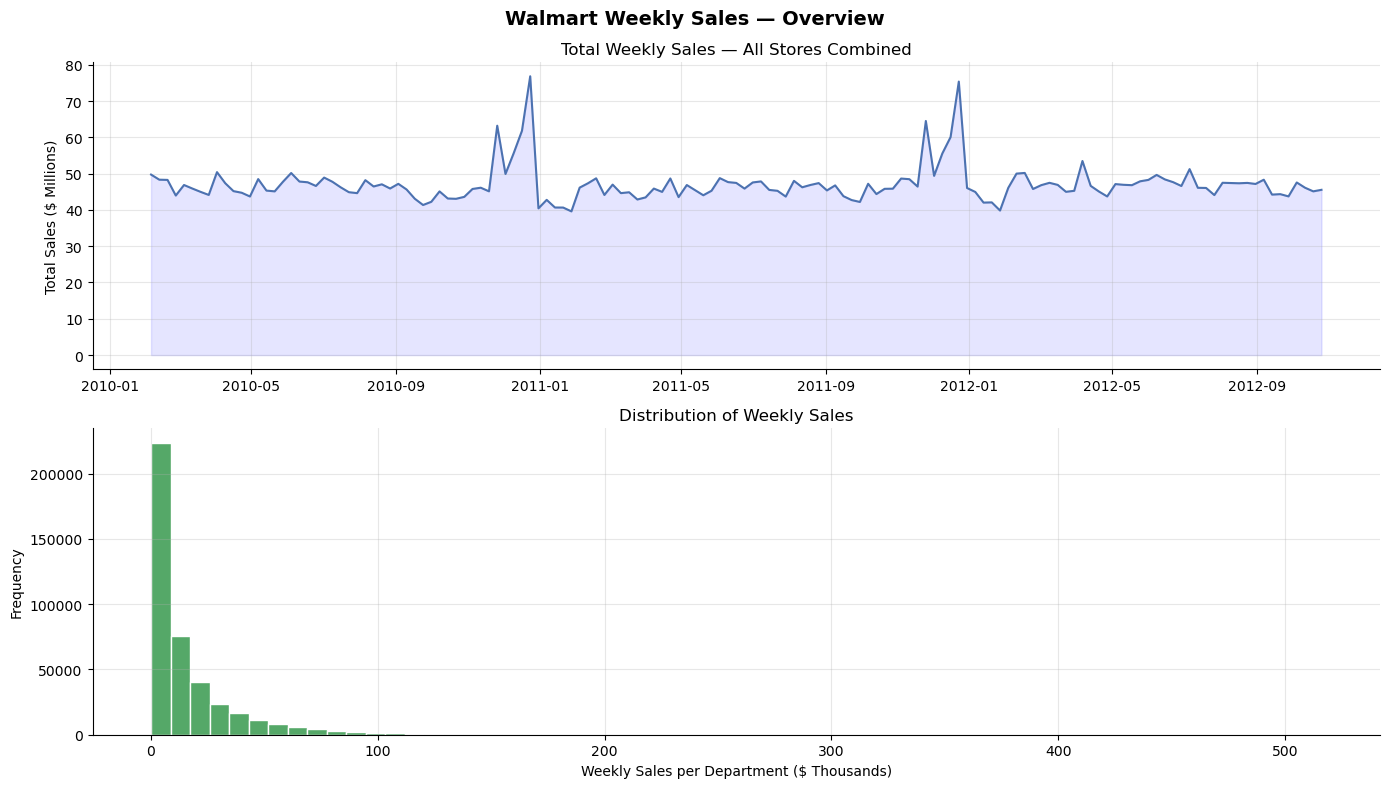

Saved to reports/figures/01_sales_overview.png


In [13]:
weekly_total = df.groupby("Date")["Weekly_Sales"].sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Walmart Weekly Sales — Overview", fontsize=14, fontweight="bold")

# Top plot: sales over time
axes[0].plot(weekly_total.index, weekly_total.values / 1e6,
             color="#4C72B0", linewidth=1.5)
axes[0].fill_between(weekly_total.index, weekly_total.values / 1e6,
                     alpha=0.1, color="blue")
axes[0].set_ylabel("Total Sales ($ Millions)")
axes[0].set_title("Total Weekly Sales — All Stores Combined")

# Bottom plot: distribution of individual department sales
axes[1].hist(df["Weekly_Sales"] / 1e3, bins=60,
             color="#55A868", edgecolor="white")
axes[1].set_xlabel("Weekly Sales per Department ($ Thousands)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Weekly Sales")

plt.tight_layout()
plt.savefig("reports/figures/01_sales_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/figures/01_sales_overview.png")

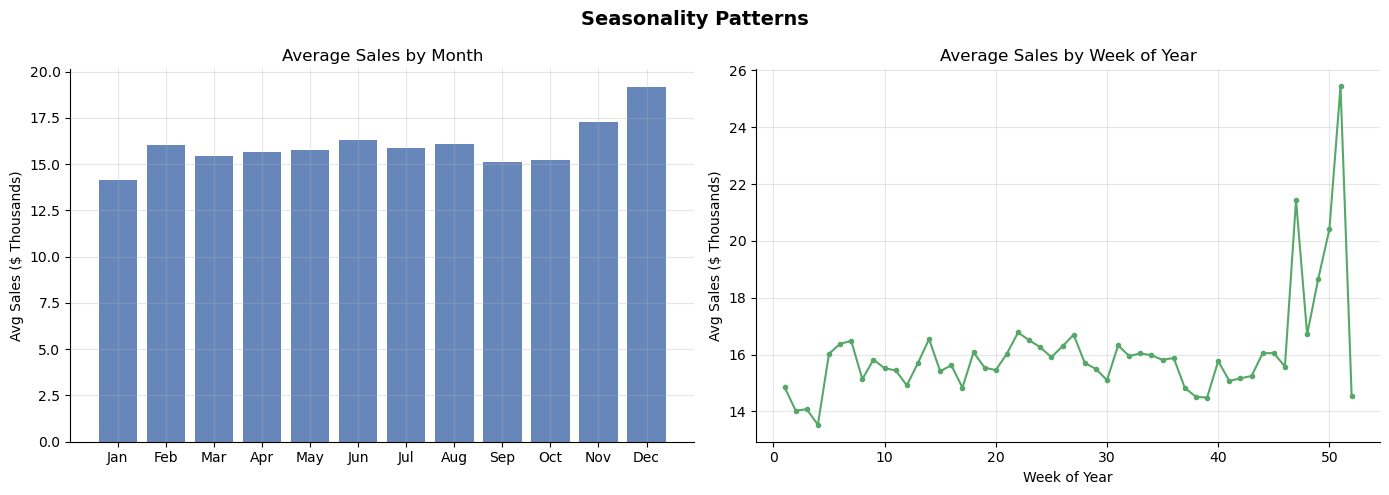

In [18]:
df["Month"] = df["Date"].dt.month
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Seasonality Patterns", fontsize=14, fontweight="bold")

# Monthly average
monthly_avg = df.groupby("Month")["Weekly_Sales"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0].bar(monthly_avg.index, monthly_avg.values / 1e3,
            color="#4C72B0", alpha=0.85)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel("Avg Sales ($ Thousands)")
axes[0].set_title("Average Sales by Month")

# Weekly average
weekly_avg = df.groupby("WeekOfYear")["Weekly_Sales"].mean()
axes[1].plot(weekly_avg.index, weekly_avg.values / 1e3,
             color="#55A868", linewidth=1.5, marker="o", markersize=3)
axes[1].set_xlabel("Week of Year")
axes[1].set_ylabel("Avg Sales ($ Thousands)")
axes[1].set_title("Average Sales by Week of Year")

plt.tight_layout()
plt.savefig("reports/figures/02_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

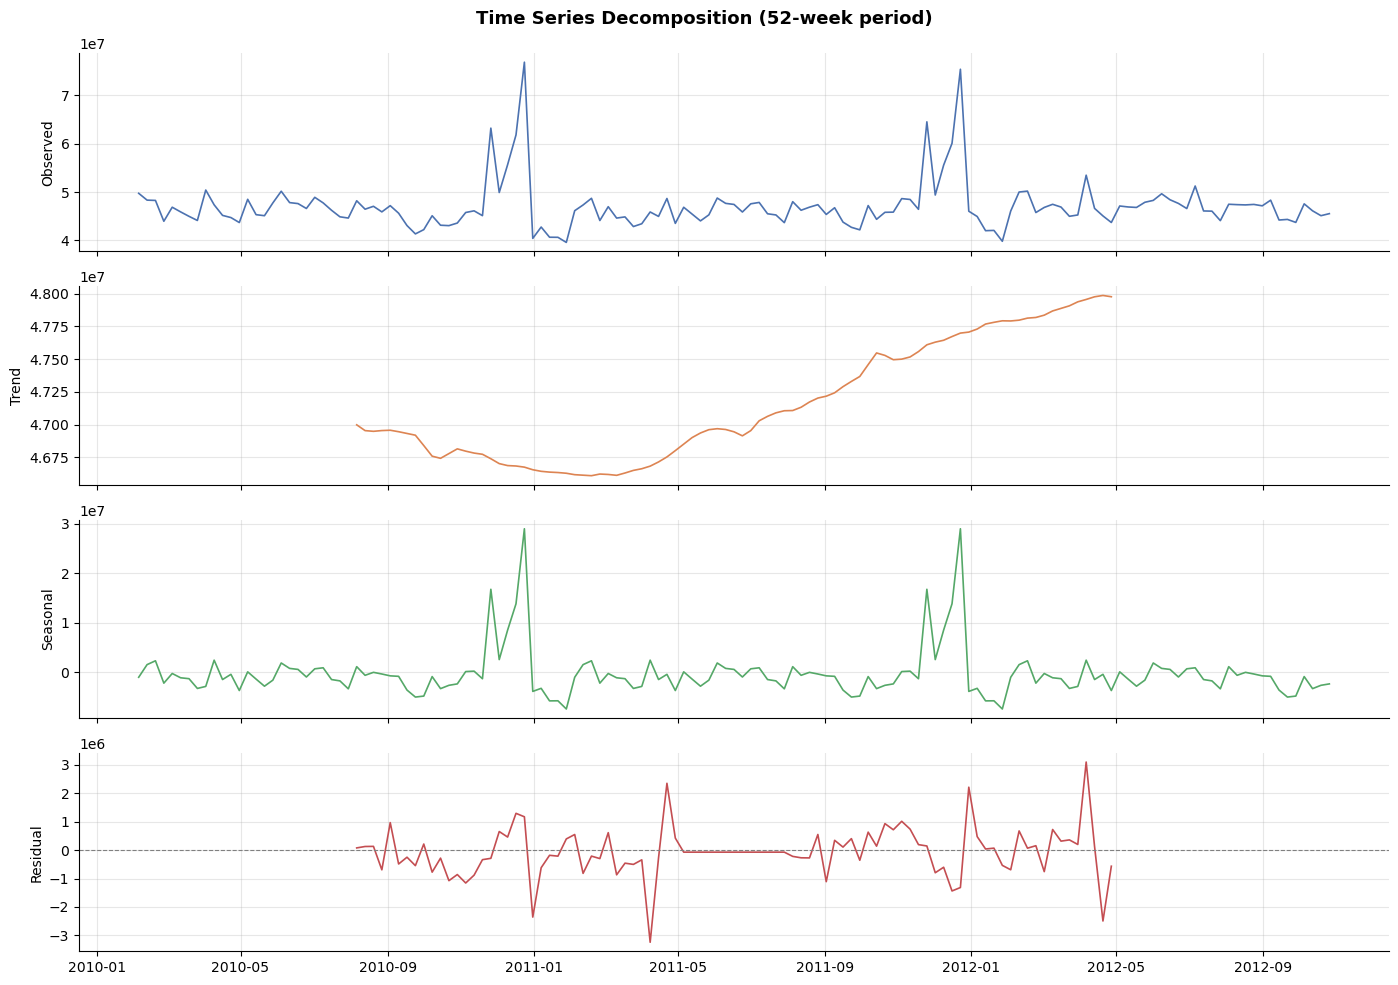

In [28]:
# Use aggregate weekly sales for decomposition
weekly_series = df.groupby("Date")["Weekly_Sales"].sum()
weekly_series.index = pd.DatetimeIndex(weekly_series.index)
weekly_series.index.freq = pd.infer_freq(weekly_series.index)

# Decompose with period=52 (52 weeks in a year)
result = seasonal_decompose(weekly_series, model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Time Series Decomposition (52-week period)", fontsize=13, fontweight="bold")

components = [
    (weekly_series, "Observed",  "#4C72B0"),
    (result.trend,  "Trend",     "#DD8452"),
    (result.seasonal, "Seasonal","#55A868"),
    (result.resid,  "Residual",  "#C44E52"),
]

for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.2)
    ax.set_ylabel(label)
    if label == "Residual":
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("reports/figures/03_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

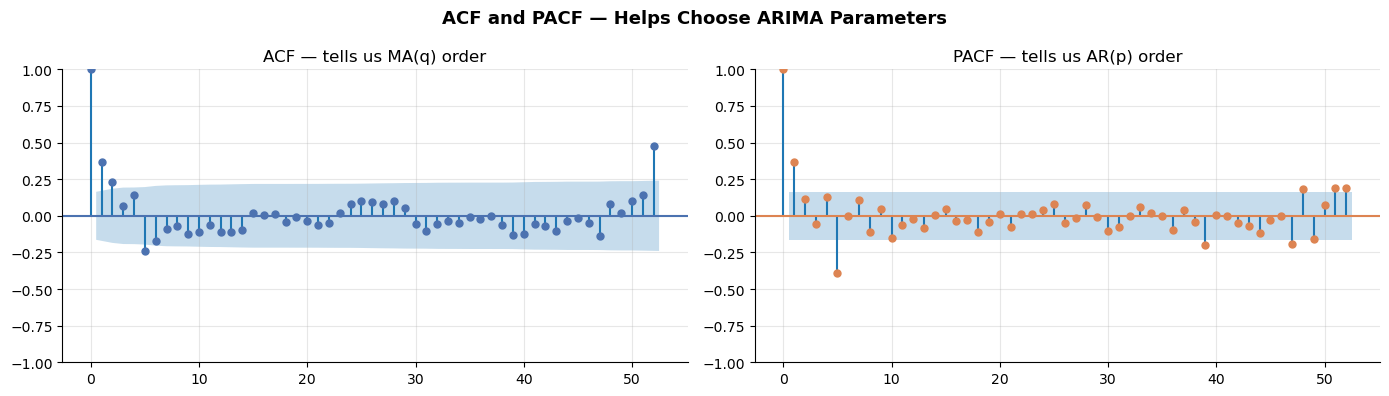

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("ACF and PACF — Helps Choose ARIMA Parameters", fontsize=13, fontweight="bold")

plot_acf(weekly_series.dropna(), lags=52, ax=axes[0], color="#4C72B0")
axes[0].set_title("ACF — tells us MA(q) order")

plot_pacf(weekly_series.dropna(), lags=52, ax=axes[1], color="#DD8452")
axes[1].set_title("PACF — tells us AR(p) order")

plt.tight_layout()
plt.savefig("reports/figures/04_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

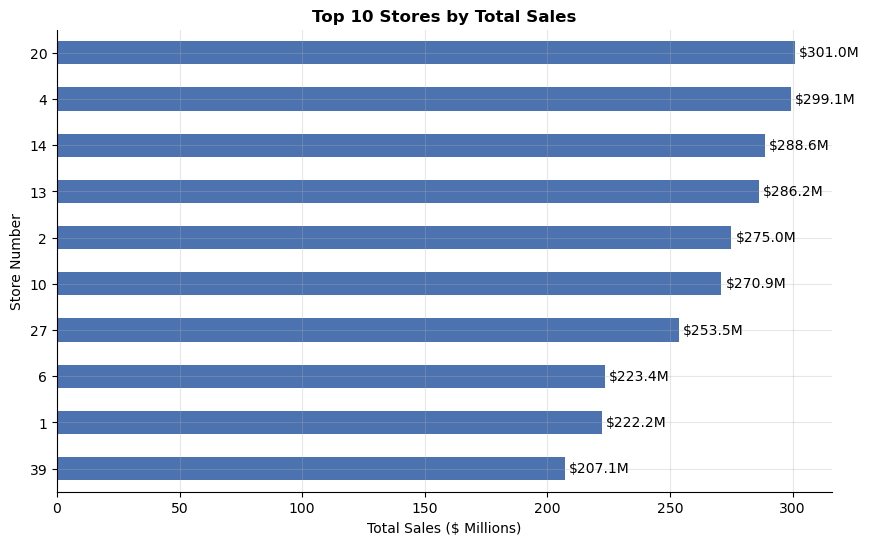

In [37]:

top_stores = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10) / 1e6


top_stores = top_stores.sort_values(ascending=True)


ax = top_stores.plot(kind="barh", figsize=(10, 6), color="#4C72B0")


ax.bar_label(ax.containers[0], fmt='$%.1fM', padding=3)


ax.set_title("Top 10 Stores by Total Sales", fontweight="bold")
ax.set_xlabel("Total Sales ($ Millions)")
ax.set_ylabel("Store Number")
plt.savefig("reports/figures/05_top_stores.png", dpi=150, bbox_inches="tight")
plt.show()

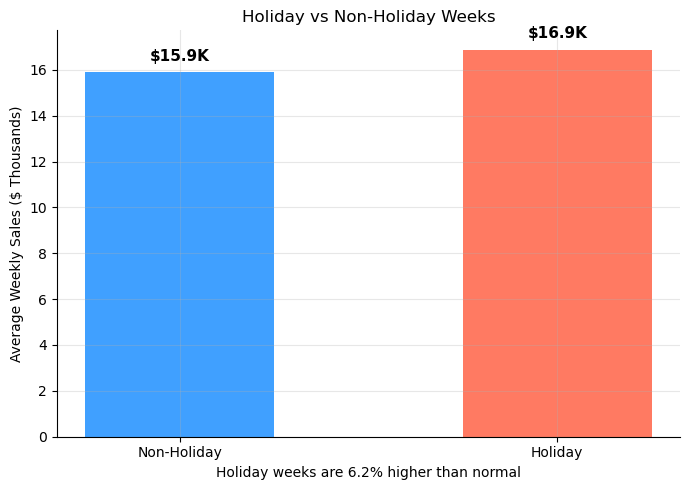

In [41]:
holiday_avg = df.groupby("IsHoliday")["Weekly_Sales"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ["Non-Holiday", "Holiday"],
    holiday_avg.values / 1e3,
    color=["dodgerblue", "tomato"],
    alpha=0.85,
    width=0.5
)
ax.set_ylabel("Average Weekly Sales ($ Thousands)")
ax.set_title("Holiday vs Non-Holiday Weeks")

for bar, val in zip(bars, holiday_avg.values / 1e3):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f"${val:.1f}K", ha="center", fontsize=11, fontweight="bold")

pct = (holiday_avg[True] / holiday_avg[False] - 1) * 100
ax.set_xlabel(f"Holiday weeks are {pct:.1f}% {'higher' if pct > 0 else 'lower'} than normal")

plt.tight_layout()
plt.savefig("reports/figures/06_holiday_impact.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
series = weekly_series.dropna()

# ADF Test — H0: data is NON-stationary
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag="AIC")

# KPSS Test — H0: data IS stationary
kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")

print("=" * 50)
print("STATIONARITY TEST RESULTS")
print("=" * 50)

print(f"\nADF Test:")
print(f"  Statistic : {adf_stat:.4f}")
print(f"  p-value   : {adf_p:.4f}")
print(f"  Result    : {'STATIONARY ✓' if adf_p < 0.05 else 'NON-STATIONARY ✗'}")

print(f"\nKPSS Test:")
print(f"  Statistic : {kpss_stat:.4f}")
print(f"  p-value   : {kpss_p:.4f}")
print(f"  Result    : {'STATIONARY ✓' if kpss_p > 0.05 else 'NON-STATIONARY ✗'}")

# Conclusion
adf_ok  = adf_p < 0.05
kpss_ok = kpss_p > 0.05

if adf_ok and kpss_ok:
    conclusion = "STATIONARY — ready for ARIMA as-is"
elif not adf_ok and not kpss_ok:
    conclusion = "NON-STATIONARY — we will need to difference the data in Phase 4"
else:
    conclusion = "CONFLICTING — check the decomposition plot visually"

print(f"\nFinal Conclusion: {conclusion}")

STATIONARITY TEST RESULTS

ADF Test:
  Statistic : -6.0902
  p-value   : 0.0000
  Result    : STATIONARY ✓

KPSS Test:
  Statistic : 0.0523
  p-value   : 0.1000
  Result    : STATIONARY ✓

Final Conclusion: STATIONARY — ready for ARIMA as-is


In [44]:
import os
os.makedirs("data/processed", exist_ok=True)

df.to_parquet("data/processed/train_clean.parquet", index=False)

print("Clean data saved to: data/processed/train_clean.parquet")
print(f"Shape: {df.shape}")
print("\nPhase 2 Complete!")
print("All 6 plots saved in: reports/figures/")

Clean data saved to: data/processed/train_clean.parquet
Shape: (421570, 18)

Phase 2 Complete!
All 6 plots saved in: reports/figures/
